<a href="https://colab.research.google.com/github/BearBearOneBear/course-ML/blob/main/MLassign3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import time

from torch.utils.data import DataLoader
from torchvision import transforms, datasets

from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

from scipy.stats import randint

import matplotlib.pylab as plt

In [6]:
def load_mnist():
    mnist_train_transform = transforms.Compose([transforms.ToTensor()])
    mnist_test_transform = transforms.Compose([transforms.ToTensor()])

    trainset_mnist = datasets.MNIST(
        root='C:/Users/Han ung/OneDrive/바탕 화면/U/5_1/머신러닝/assign1',
        train=True,
        download=True,
        transform=mnist_train_transform
    )

    testset_mnist = datasets.MNIST(
        root='C:/Users/Han ung/OneDrive/바탕 화면/U/5_1/머신러닝/assign1',
        train=False,
        download=True,
        transform=mnist_test_transform
    )

    MNIST_train = DataLoader(trainset_mnist, batch_size=32, shuffle=True, num_workers=0)
    MNIST_test = DataLoader(testset_mnist, batch_size=32, shuffle=False, num_workers=0)

    MNIST_train_images = []
    MNIST_train_labels = []

    for images, labels in MNIST_train:
        images_flat = images.view(images.shape[0], -1)
        MNIST_train_images.append(images_flat.numpy())
        MNIST_train_labels.append(labels.numpy())

    MNIST_train_images = np.vstack(MNIST_train_images)
    MNIST_train_labels = np.concatenate(MNIST_train_labels)

    MNIST_test_images = []
    MNIST_test_labels = []

    for images, labels in MNIST_test:
        images_flat = images.view(images.shape[0], -1)
        MNIST_test_images.append(images_flat.numpy())
        MNIST_test_labels.append(labels.numpy())

    MNIST_test_images = np.vstack(MNIST_test_images)
    MNIST_test_labels = np.concatenate(MNIST_test_labels)

    return MNIST_train_images, MNIST_train_labels, MNIST_test_images, MNIST_test_labels

In [7]:
def load_cifar10():
    CIFAR_transform_train = transforms.Compose([transforms.ToTensor()])
    CIFAR_transform_test = transforms.Compose([transforms.ToTensor()])

    trainset_CIFAR = datasets.CIFAR10(
        root='C:/Users/Han ung/OneDrive/바탕 화면/U/5_1/머신러닝/assign1',
        train=True,
        download=True,
        transform=CIFAR_transform_train
    )

    testset_CIFAR = datasets.CIFAR10(
        root='C:/Users/Han ung/OneDrive/바탕 화면/U/5_1/머신러닝/assign1',
        train=False,
        download=True,
        transform=CIFAR_transform_test
    )

    CIFAR_train = DataLoader(trainset_CIFAR, batch_size=32, shuffle=True, num_workers=0)
    CIFAR_test = DataLoader(testset_CIFAR, batch_size=32, shuffle=False, num_workers=0)

    CIFAR_train_images = []
    CIFAR_train_labels = []

    for images, labels in CIFAR_train:
        images_flat = images.view(images.shape[0], -1)
        CIFAR_train_images.append(images_flat.numpy())
        CIFAR_train_labels.append(labels.numpy())

    CIFAR_train_images = np.vstack(CIFAR_train_images)
    CIFAR_train_labels = np.concatenate(CIFAR_train_labels)

    CIFAR_test_images = []
    CIFAR_test_labels = []

    for images, labels in CIFAR_test:
        images_flat = images.view(images.shape[0], -1)
        CIFAR_test_images.append(images_flat.numpy())
        CIFAR_test_labels.append(labels.numpy())

    CIFAR_test_images = np.vstack(CIFAR_test_images)
    CIFAR_test_labels = np.concatenate(CIFAR_test_labels)

    return CIFAR_train_images, CIFAR_train_labels, CIFAR_test_images, CIFAR_test_labels

In [8]:
MNIST_X_train, MNIST_y_train, MNIST_X_test, MNIST_y_test = load_mnist()
CIFAR_X_train, CIFAR_y_train, CIFAR_X_test, CIFAR_y_test = load_cifar10()

print("MNIST train:", MNIST_X_train.shape, MNIST_y_train.shape)
print("MNIST test :", MNIST_X_test.shape, MNIST_y_test.shape)

print("CIFAR train:", CIFAR_X_train.shape, CIFAR_y_train.shape)
print("CIFAR test :", CIFAR_X_test.shape, CIFAR_y_test.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]
100%|██████████| 170M/170M [05:15<00:00, 540kB/s]


MNIST train: (60000, 784) (60000,)
MNIST test : (10000, 784) (10000,)
CIFAR train: (50000, 3072) (50000,)
CIFAR test : (10000, 3072) (10000,)


In [9]:
MNIST_X_train_small = MNIST_X_train[:5000]
MNIST_y_train_small = MNIST_y_train[:5000]
MNIST_X_test_small = MNIST_X_test[:1000]
MNIST_y_test_small = MNIST_y_test[:1000]

CIFAR_X_train_small = CIFAR_X_train[:5000]
CIFAR_y_train_small = CIFAR_y_train[:5000]
CIFAR_X_test_small = CIFAR_X_test[:1000]
CIFAR_y_test_small = CIFAR_y_test[:1000]

print(MNIST_X_train_small.shape, MNIST_y_train_small.shape)
print(CIFAR_X_train_small.shape, CIFAR_y_train_small.shape)

(5000, 784) (5000,)
(5000, 3072) (5000,)


In [ ]:
class DecisionTree:
    def __init__(self, max_depth = 12, min_samples_split = 2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.predict_depth = max_depth
        self.root = None

  # learning (fit)
    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth = 0)
  # inference (predict)
    def predict(self, X):
        predictions = []

        for x in X:
            pred = self._predict_one(x, self.root, depth = 0)
            predictions.append(pred)

        return np.array(predictions)


    def _build_tree(self, X, y, depth):
        major_class = self._major_class(y)
        # 1. stop condition
        if (
            depth > self.max_depth - 1 or
            len(y) < self.min_samples_split or
            len(np.unique(y)) == 1
        ):
          return {
              "type" : "leaf",
              "class" : major_class
          }

        # 2. find best split
        best_feature, best_threshold = self._best_split(X, y)
        # 2.1 no best feature
        if best_feature is None:
            return {
              "type" : "leaf",
              "class" : major_class
          }

        # 3. split data
        i_left = X[:, best_feature] <= best_threshold
        i_right = X[:, best_feature] > best_threshold
        X_left = X[i_left]
        y_left = y[i_left]
        X_right = X[i_right]
        y_right = y[i_right]

        # 4. recursively build child nodes
        c_left = self._build_tree(X_left, y_left, depth + 1)
        c_right = self._build_tree(X_right, y_right, depth + 1)

        return {
            "type" : "node",
            "feature" : best_feature,
            "threshold" : best_threshold,
            "major_class" : major_class,
            "left" : c_left,
            "right" : c_right
        }

    def _best_split(self, X, y):
        best_feature = None
        best_threshold = None
        best_gain = 0
        numsamples, numfeatures = X.shape
    #### use median for thresholds ####
        thresholds = np.median(X, axis = 0)
      # thresholds = np.mean(X, axis = 0)
    #### use median for thresholds ####
        for feature in range(numfeatures):
          threshold = thresholds[feature]
          feature_values = X[:, feature]

          m_left = feature_values <= threshold
          m_right = ~m_left

          n_left = np.sum(m_left)
          n_right = numsamples - n_left
          # same value, different label
          if n_left == 0 or n_right == 0:
            continue
          y_left = y[m_left]
          y_right = y[m_right]

          information_gain = self._information_gain(y, y_left, y_right)

          if information_gain > best_gain:
            best_gain = information_gain
            best_feature = feature
            best_threshold = threshold

        return best_feature, best_threshold

    def _entropy(self, y):
        classes, counts = np.unique(y, return_counts=True)
        p = counts / len(y)
        entropy = -np.sum(p * np.log2(p + 1e-9))

        return entropy

    def _information_gain(self, y, y_left, y_right):
        e_parent = self._entropy(y)
        e_left = self._entropy(y_left)
        e_right = self._entropy(y_right)

        e_child = (
            len(y_left) * e_left + len(y_right) * e_right
        ) / len(y)

        information_gain = e_parent - e_child

        return information_gain

    def _major_class(self, y):
        classes, counts = np.unique(y, return_counts = True)
        major_index = np.argmax(counts)

        return classes[major_index]

    def set_predict_depth(self, depth):
      self.predict_depth = depth

    def _predict_one(self, x, node, depth = 0):
        # 1. leaf node
        if node["type"] == "leaf":
          return node["class"]
        # 2. predict depth
        if depth > self.predict_depth - 1:
          return node["major_class"]

        feature = node["feature"]
        threshold = node["threshold"]
        # 3. branching
        if x[feature] <= threshold:
          return self._predict_one(x, node["left"], depth + 1)
        else:
          return self._predict_one(x, node["right"], depth + 1)

In [ ]:
def run_decision_tree(dataset, X_train, y_train, X_test, y_test):
    print(f"==== Decision Tree == {dataset} ====")

    depths = [3, 6, 9, 12]
    results = []

     # learning only depth 12
    start_time = time.time()

    tree = DecisionTree(max_depth=12)
    tree.fit(X_train, y_train)

    end_time = time.time()
    run_time = end_time - start_time

    # prediction vairous depth 3, 6, 9, 12
    for depth in [3, 6, 9, 12]:
        tree.set_predict_depth(depth)

        train_pred = tree.predict(X_train)
        test_pred = tree.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)

        results.append(["Decision Tree", depth, train_acc, test_acc, run_time])

    return results

In [ ]:
def run_linear_svm(dataset, X_train, y_train, X_test, y_test):
    print(f"==== LSVM == {dataset} ====")

    results = []

    # learning linear svm
    start_time = time.time()

    linear_model = svm.SVC(kernel = 'linear', C = 1.0)
    linear_model.fit(X_train, y_train)

    end_time = time.time()
    run_time = end_time - start_time

    # prediction
    train_pred = linear_model.predict(X_train)
    test_pred = linear_model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append(["Linear SVM", train_acc, test_acc, run_time])

    return results

In [ ]:
def run_rbf_svm(dataset, X_train, y_train, X_test, y_test):
    print(f"==== RSVM == {dataset} ====")

    results = []

    # learning RBF svm
    start_time = time.time()

    rbf_model = svm.SVC(kernel = 'rbf', C = 1.0, gamma = 'scale')
    rbf_model.fit(X_train, y_train)

    end_time = time.time()
    run_time = end_time - start_time

    # prediction
    train_pred = rbf_model.predict(X_train)
    test_pred = rbf_model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append(["RBF SVM", train_acc, test_acc, run_time])

    return results

In [ ]:
def run_dt_gridsearch(dataset, X_train, y_train, X_test, y_test):
    print(f"==== Decision Tree GridSearchCV == {dataset} ====")

    depths = [3, 6, 9, 12]

    # grid pool
    params_grid = {
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_leaf_nodes": [5, 10, None]
    }

    results = []

    for depth in depths:
        model = DecisionTreeClassifier(
            max_depth = depth,
            random_state=42
        )

        grid = GridSearchCV(
            estimator = model,
            param_grid = params_grid,
            cv = 5,
            scoring = "accuracy",
            n_jobs = -1
        )
        # learning
        start_time = time.time()
        grid.fit(X_train, y_train)
        end_time = time.time()

        best_model = grid.best_estimator_

        # prediction
        train_pred = best_model.predict(X_train)
        test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        run_time = end_time - start_time

        results.append([
            "Decision Tree",
            depth,
            grid.best_params_,
            train_acc,
            test_acc,
            run_time
        ])

    return results

In [ ]:
def run_lsvm_gridsearch(dataset, X_train, y_train, X_test, y_test):
    print(f"==== Linear SVM GridSearchCV == {dataset} ====")

    # grid pool
    params_grid = {
        "C": [0.1, 1.0, 10.0]
    }

    model = svm.SVC(
        kernel="linear"
    )

    grid = GridSearchCV(
        estimator=model,
        param_grid=params_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    # learning
    start_time = time.time()
    grid.fit(X_train, y_train)
    end_time = time.time()

    best_model = grid.best_estimator_

    # prediction
    train_pred = best_model.predict(X_train)
    test_pred = best_model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    run_time = end_time - start_time

    results = [[
        "Linear SVM",
        grid.best_params_,
        train_acc,
        test_acc,
        run_time
    ]]

    return results

In [ ]:
def run_rsvm_gridsearch(dataset, X_train, y_train, X_test, y_test):
    print(f"==== RBF SVM GridSearchCV == {dataset} ====")

    # grid pool
    params_grid = {
        "C": [0.1, 1.0, 10.0],
        "gamma": ["scale", "auto"]
    }

    model = svm.SVC(
        kernel="rbf"
    )

    grid = GridSearchCV(
        estimator=model,
        param_grid=params_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    #learning
    start_time = time.time()
    grid.fit(X_train, y_train)
    end_time = time.time()

    best_model = grid.best_estimator_

    # prediction
    train_pred = best_model.predict(X_train)
    test_pred = best_model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    run_time = end_time - start_time

    results = [[
        "RBF SVM",
        grid.best_params_,
        train_acc,
        test_acc,
        run_time
    ]]

    return results

In [ ]:
mnist_dt_results = run_decision_tree(
    "MNIST",
    MNIST_X_train_small,
    MNIST_y_train_small,
    MNIST_X_test_small,
    MNIST_y_test_small
)
print(f"{mnist_dt_results[0][4]:.2f}")

==== Decision Tree == MNIST ====
28.67


In [ ]:
mnist_lsvm_results = run_linear_svm(
    "MNIST",
    MNIST_X_train_small,
    MNIST_y_train_small,
    MNIST_X_test_small,
    MNIST_y_test_small
)
print(f"{mnist_lsvm_results[0][3]:.2f}")


==== LSVM == MNIST ====
2.40


In [ ]:
mnist_rsvm_results = run_rbf_svm(
    "MNIST",
    MNIST_X_train_small,
    MNIST_y_train_small,
    MNIST_X_test_small,
    MNIST_y_test_small
)
print(f"{mnist_rsvm_results[0][3]:.2f}")

==== RSVM == MNIST ====
3.30


In [ ]:
cifar_dt_results = run_decision_tree(
    "CIFAR-10",
    CIFAR_X_train_small,
    CIFAR_y_train_small,
    CIFAR_X_test_small,
    CIFAR_y_test_small
)
print(f"{cifar_dt_results[0][4]:.2f}")

==== Decision Tree == CIFAR-10 ====
587.39


In [ ]:
cifar_lsvm_results = run_linear_svm(
    "CIFAR-10",
    CIFAR_X_train_small,
    CIFAR_y_train_small,
    CIFAR_X_test_small,
    CIFAR_y_test_small
)
print(f"{cifar_lsvm_results[0][3]:.2f}")

==== LSVM == CIFAR-10 ====
86.87


In [ ]:
cifar_rsvm_results = run_rbf_svm(
    "CIFAR-10",
    CIFAR_X_train_small,
    CIFAR_y_train_small,
    CIFAR_X_test_small,
    CIFAR_y_test_small
)
print(f"{cifar_rsvm_results[0][3]:.2f}")

==== RSVM == CIFAR-10 ====
76.67


In [ ]:
mnist_dt_grid_results = run_dt_gridsearch(
    "MNIST",
    MNIST_X_train_small,
    MNIST_y_train_small,
    MNIST_X_test_small,
    MNIST_y_test_small
)

for row in mnist_dt_grid_results:
    print(f"{row[1]} : {row[5]:.2f}")

==== Decision Tree GridSearchCV == MNIST ====

[Decision Tree] depth = 3

[Decision Tree] depth = 6

[Decision Tree] depth = 9

[Decision Tree] depth = 12
Depth 3 GridSearch Time: 37.58s
Depth 6 GridSearch Time: 47.40s
Depth 9 GridSearch Time: 56.46s
Depth 12 GridSearch Time: 61.52s


In [ ]:
mnist_lsvm_grid_results = run_lsvm_gridsearch(
    "MNIST",
    MNIST_X_train_small,
    MNIST_y_train_small,
    MNIST_X_test_small,
    MNIST_y_test_small
)

print(f"{mnist_lsvm_grid_results[0][4]:.2f}")

==== Linear SVM GridSearchCV == MNIST ====
Linear SVM GridSearch Time: 35.98s


In [ ]:
mnist_rsvm_grid_results = run_rsvm_gridsearch(
    "MNIST",
    MNIST_X_train_small,
    MNIST_y_train_small,
    MNIST_X_test_small,
    MNIST_y_test_small
)

print(f"{mnist_rsvm_grid_results[0][4]:.2f}")

==== RBF SVM GridSearchCV == MNIST ====
RBF SVM GridSearch Time: 186.44s


In [ ]:
cifar_dt_grid_results = run_dt_gridsearch(
    "CIFAR-10",
    CIFAR_X_train_small,
    CIFAR_y_train_small,
    CIFAR_X_test_small,
    CIFAR_y_test_small
)

for row in cifar_dt_grid_results:
    print(f"{row[1]} : {row[5]:.2f}")

==== Decision Tree GridSearchCV == CIFAR-10 ====

[Decision Tree] depth = 3

[Decision Tree] depth = 6

[Decision Tree] depth = 9

[Decision Tree] depth = 12
Depth 3 GridSearch Time: 379.98s
Depth 6 GridSearch Time: 581.47s
Depth 9 GridSearch Time: 756.29s
Depth 12 GridSearch Time: 878.26s


In [ ]:
cifar_lsvm_grid_results = run_lsvm_gridsearch(
    "CIFAR-10",
    CIFAR_X_train_small,
    CIFAR_y_train_small,
    CIFAR_X_test_small,
    CIFAR_y_test_small
)

print(f"{cifar_lsvm_grid_results[0][4]:.2f}")

==== Linear SVM GridSearchCV == CIFAR-10 ====
Linear SVM GridSearch Time: 883.51s


In [ ]:
cifar_rsvm_grid_results = run_rsvm_gridsearch(
    "CIFAR-10",
    CIFAR_X_train_small,
    CIFAR_y_train_small,
    CIFAR_X_test_small,
    CIFAR_y_test_small
)

print(f"{cifar_rsvm_grid_results[0][4]:.2f}")

==== RBF SVM GridSearchCV == CIFAR-10 ====
RBF SVM GridSearch Time: 1944.51s


In [ ]:
def print_dt_results(title, results):
    print("\n==============================")
    print(title)
    print("==============================")

    for row in results:
        # Original
        if len(row) == 5:
            model, depth, train_acc, test_acc, run_time = row

            print(
                f"{model:20s} | "
                f"Depth = {depth:2d} | "
                f"Train = {train_acc:.4f} | "
                f"Test = {test_acc:.4f} | "
                f"Time = {run_time:.2f}s"
            )

        # Grid Search CV
        elif len(row) == 6:
            model, depth, best_params, train_acc, test_acc, run_time = row

            print(
                f"{model:20s} | "
                f"Depth = {depth:2d} | "
                f"Train = {train_acc:.4f} | "
                f"Test = {test_acc:.4f} | "
                f"Time = {run_time:.2f}s | "
                f"Best = {best_params}"
            )


def print_svm_results(title, results):
    print("\n==============================")
    print(title)
    print("==============================")

    for row in results:
        # Original
        if len(row) == 4:
            model, train_acc, test_acc, run_time = row

            print(
                f"{model:20s} | "
                f"Train = {train_acc:.4f} | "
                f"Test = {test_acc:.4f} | "
                f"Time = {run_time:.2f}s"
            )

        # Grid Search CV
        elif len(row) == 5:
            model, best_params, train_acc, test_acc, run_time = row

            print(
                f"{model:20s} | "
                f"Train = {train_acc:.4f} | "
                f"Test = {test_acc:.4f} | "
                f"Time = {run_time:.2f}s | "
                f"Best = {best_params}"
            )

In [ ]:
print_dt_results(
    "MNIST Decision Tree Results",
    mnist_dt_results
)

print_svm_results(
    "MNIST Linear SVM Results",
    mnist_lsvm_results
)

print_svm_results(
    "MNIST RBF SVM Results",
    mnist_rsvm_results
)

print_dt_results(
    "CIFAR-10 Decision Tree Results",
    cifar_dt_results
)

print_svm_results(
    "CIFAR-10 Linear SVM Results",
    cifar_lsvm_results
)

print_svm_results(
    "CIFAR-10 RBF SVM Results",
    cifar_rsvm_results
)




print_dt_results(
    "MNIST Decision Tree GridSearchCV Results",
    mnist_dt_grid_results
)

print_svm_results(
    "MNIST Linear SVM GridSearchCV Results",
    mnist_lsvm_grid_results
)

print_svm_results(
    "MNIST RBF SVM GridSearchCV Results",
    mnist_rsvm_grid_results
)

print_dt_results(
    "CIFAR-10 Decision Tree GridSearchCV Results",
    cifar_dt_grid_results
)

print_svm_results(
    "CIFAR-10 Linear SVM GridSearchCV Results",
    cifar_lsvm_grid_results
)

print_svm_results(
    "CIFAR-10 RBF SVM GridSearchCV Results",
    cifar_rsvm_grid_results
)


MNIST Decision Tree Results
Decision Tree        | Depth =  3 | Train = 0.5102 | Test = 0.5060 | Time = 28.67s
Decision Tree        | Depth =  6 | Train = 0.7554 | Test = 0.6880 | Time = 28.67s
Decision Tree        | Depth =  9 | Train = 0.9316 | Test = 0.7630 | Time = 28.67s
Decision Tree        | Depth = 12 | Train = 0.9920 | Test = 0.7750 | Time = 28.67s

MNIST Linear SVM Results
Linear SVM           | Train = 1.0000 | Test = 0.9080 | Time = 2.40s

MNIST RBF SVM Results
RBF SVM              | Train = 0.9866 | Test = 0.9370 | Time = 3.30s

CIFAR-10 Decision Tree Results
Decision Tree        | Depth =  3 | Train = 0.2392 | Test = 0.2260 | Time = 587.39s
Decision Tree        | Depth =  6 | Train = 0.3254 | Test = 0.2550 | Time = 587.39s
Decision Tree        | Depth =  9 | Train = 0.6478 | Test = 0.2220 | Time = 587.39s
Decision Tree        | Depth = 12 | Train = 0.9948 | Test = 0.1960 | Time = 587.39s

CIFAR-10 Linear SVM Results
Linear SVM           | Train = 0.9912 | Test = 0.3310 |

In [10]:
mnist_dt_results = [
    ["Decision Tree", 3, 0.5102, 0.5060, 28.67],
    ["Decision Tree", 6, 0.7554, 0.6880, 28.67],
    ["Decision Tree", 9, 0.9316, 0.7630, 28.67],
    ["Decision Tree", 12, 0.9920, 0.7750, 28.67],
]

mnist_lsvm_results = [
    ["Linear SVM", 1.0000, 0.9080, 2.40]
]

mnist_rsvm_results = [
    ["RBF SVM", 0.9866, 0.9370, 3.30]
]

cifar_dt_results = [
    ["Decision Tree", 3, 0.2392, 0.2260, 587.39],
    ["Decision Tree", 6, 0.3254, 0.2550, 587.39],
    ["Decision Tree", 9, 0.6478, 0.2220, 587.39],
    ["Decision Tree", 12, 0.9948, 0.1960, 587.39],
]

cifar_lsvm_results = [
    ["Linear SVM", 0.9912, 0.3310, 86.87]
]

cifar_rsvm_results = [
    ["RBF SVM", 0.7168, 0.4190, 76.67]
]

mnist_dt_grid_results = [
    ["Decision Tree", 3, {'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}, 0.4938, 0.4880, 37.58],
    ["Decision Tree", 6, {'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}, 0.7676, 0.7120, 47.40],
    ["Decision Tree", 9, {'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}, 0.9284, 0.7730, 56.46],
    ["Decision Tree", 12, {'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}, 0.9836, 0.7630, 61.52],
]

mnist_lsvm_grid_results = [
    ["Linear SVM", {'C': 0.1}, 0.9842, 0.9150, 35.98]
]

mnist_rsvm_grid_results = [
    ["RBF SVM", {'C': 10.0, 'gamma': 'scale'}, 1.0000, 0.9450, 186.44]
]


cifar_dt_grid_results = [
    ["Decision Tree", 3, {'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}, 0.2482, 0.2360, 379.98],
    ["Decision Tree", 6, {'max_leaf_nodes': None, 'min_samples_leaf': 4, 'min_samples_split': 2}, 0.3506, 0.2400, 581.47],
    ["Decision Tree", 9, {'max_leaf_nodes': None, 'min_samples_leaf': 4, 'min_samples_split': 10}, 0.4992, 0.2360, 756.29],
    ["Decision Tree", 12, {'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 5}, 0.7098, 0.2300, 878.26],
]

cifar_lsvm_grid_results = [
    ["Linear SVM", {'C': 0.1}, 0.7518, 0.3690, 883.51]
]

cifar_rsvm_grid_results = [
    ["RBF SVM", {'C': 10.0, 'gamma': 'scale'}, 0.9966, 0.4200, 1944.51]
]

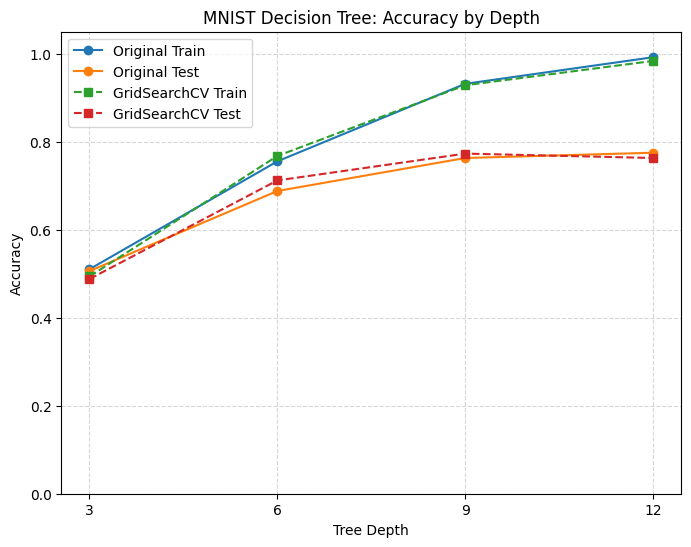

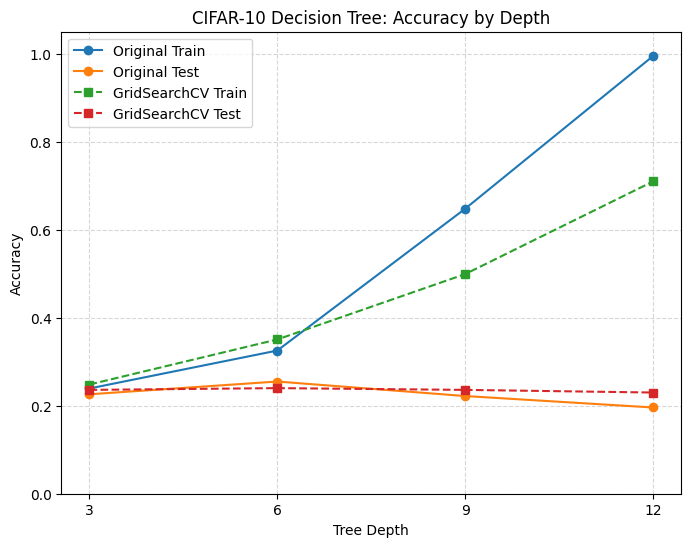

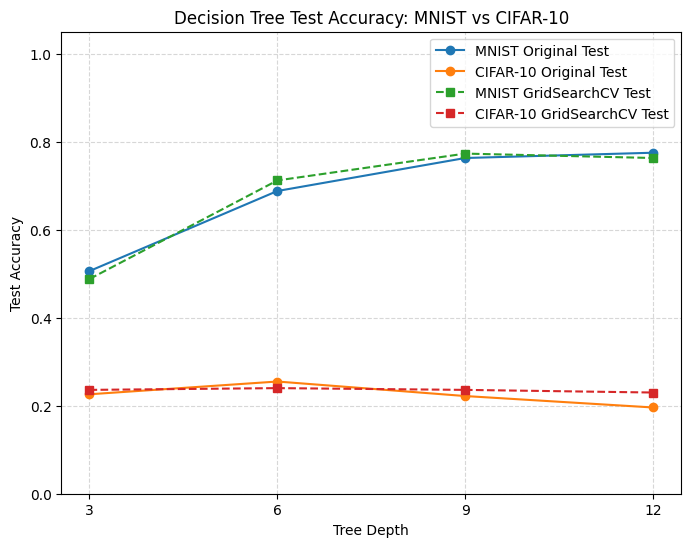

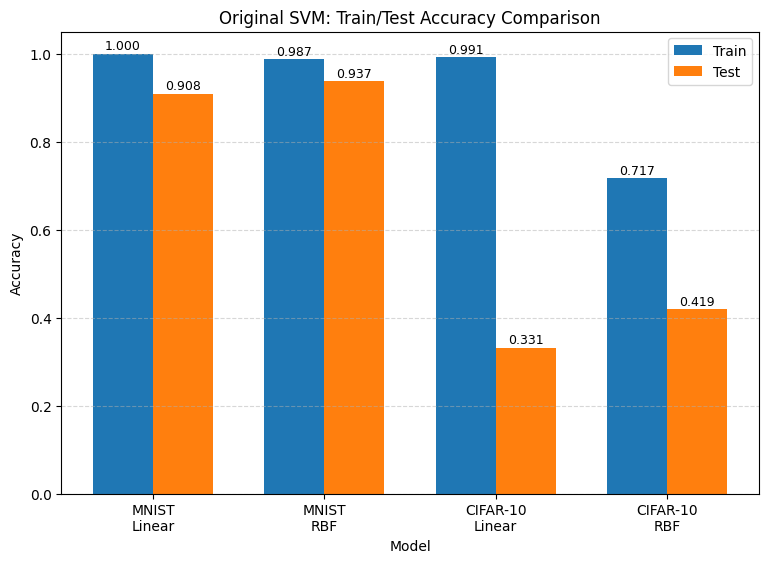

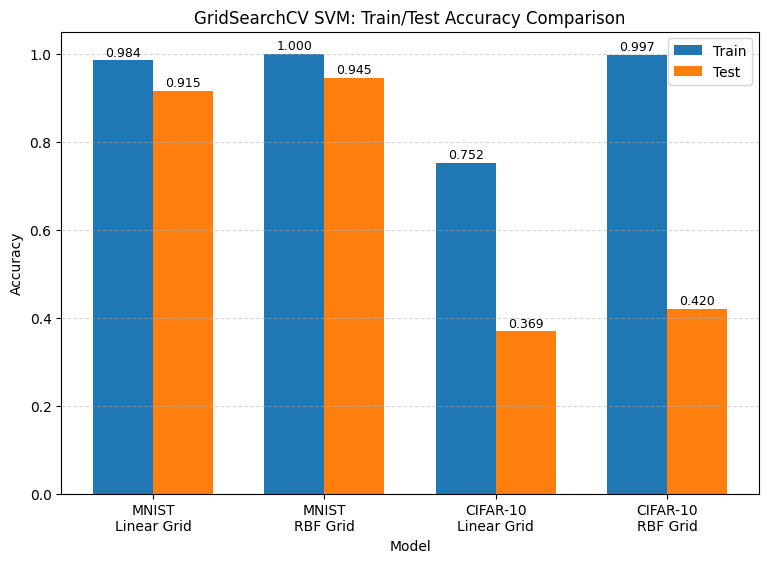

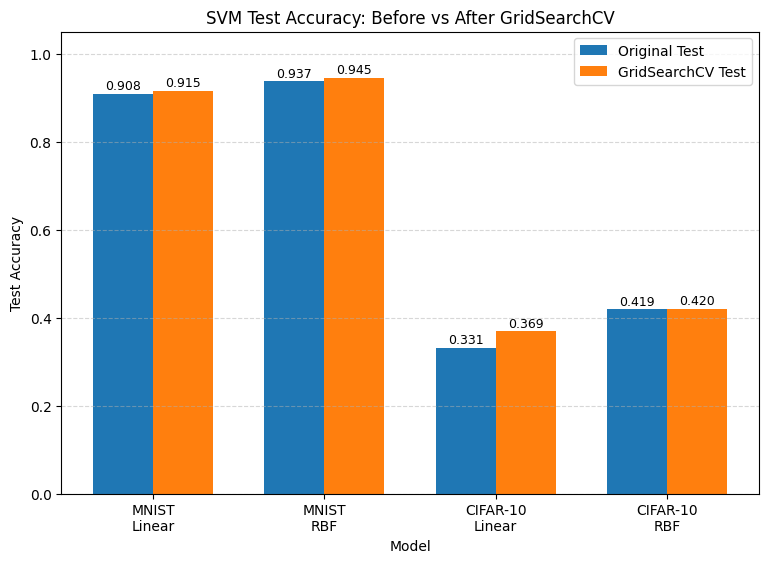

In [15]:
def plot_mnist_dt_depth(
    mnist_dt_results,
    mnist_dt_grid_results
):
    depths = [row[1] for row in mnist_dt_results]

    original_train = [row[2] for row in mnist_dt_results]
    original_test = [row[3] for row in mnist_dt_results]

    grid_train = [row[3] for row in mnist_dt_grid_results]
    grid_test = [row[4] for row in mnist_dt_grid_results]

    plt.figure(figsize=(8, 6))

    plt.plot(depths, original_train, marker='o', label='Original Train')
    plt.plot(depths, original_test, marker='o', label='Original Test')
    plt.plot(depths, grid_train, marker='s', linestyle='--', label='GridSearchCV Train')
    plt.plot(depths, grid_test, marker='s', linestyle='--', label='GridSearchCV Test')

    plt.title('MNIST Decision Tree: Accuracy by Depth')
    plt.xlabel('Tree Depth')
    plt.ylabel('Accuracy')
    plt.xticks(depths)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


def plot_cifar_dt_depth(
    cifar_dt_results,
    cifar_dt_grid_results
):
    depths = [row[1] for row in cifar_dt_results]

    original_train = [row[2] for row in cifar_dt_results]
    original_test = [row[3] for row in cifar_dt_results]

    grid_train = [row[3] for row in cifar_dt_grid_results]
    grid_test = [row[4] for row in cifar_dt_grid_results]

    plt.figure(figsize=(8, 6))

    plt.plot(depths, original_train, marker='o', label='Original Train')
    plt.plot(depths, original_test, marker='o', label='Original Test')
    plt.plot(depths, grid_train, marker='s', linestyle='--', label='GridSearchCV Train')
    plt.plot(depths, grid_test, marker='s', linestyle='--', label='GridSearchCV Test')

    plt.title('CIFAR-10 Decision Tree: Accuracy by Depth')
    plt.xlabel('Tree Depth')
    plt.ylabel('Accuracy')
    plt.xticks(depths)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


def plot_dt_dataset_comparison(
    mnist_dt_results,
    cifar_dt_results,
    mnist_dt_grid_results,
    cifar_dt_grid_results
):
    depths = [row[1] for row in mnist_dt_results]

    mnist_original_test = [row[3] for row in mnist_dt_results]
    cifar_original_test = [row[3] for row in cifar_dt_results]

    mnist_grid_test = [row[4] for row in mnist_dt_grid_results]
    cifar_grid_test = [row[4] for row in cifar_dt_grid_results]

    plt.figure(figsize=(8, 6))

    plt.plot(depths, mnist_original_test, marker='o', label='MNIST Original Test')
    plt.plot(depths, cifar_original_test, marker='o', label='CIFAR-10 Original Test')
    plt.plot(depths, mnist_grid_test, marker='s', linestyle='--', label='MNIST GridSearchCV Test')
    plt.plot(depths, cifar_grid_test, marker='s', linestyle='--', label='CIFAR-10 GridSearchCV Test')

    plt.title('Decision Tree Test Accuracy: MNIST vs CIFAR-10')
    plt.xlabel('Tree Depth')
    plt.ylabel('Test Accuracy')
    plt.xticks(depths)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


def plot_original_svm_train_test(
    mnist_lsvm_results,
    mnist_rsvm_results,
    cifar_lsvm_results,
    cifar_rsvm_results
):
    labels = [
        'MNIST\nLinear',
        'MNIST\nRBF',
        'CIFAR-10\nLinear',
        'CIFAR-10\nRBF'
    ]

    train_acc = [
        mnist_lsvm_results[0][1],
        mnist_rsvm_results[0][1],
        cifar_lsvm_results[0][1],
        cifar_rsvm_results[0][1]
    ]

    test_acc = [
        mnist_lsvm_results[0][2],
        mnist_rsvm_results[0][2],
        cifar_lsvm_results[0][2],
        cifar_rsvm_results[0][2]
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(9, 6))

    plt.bar(x - width / 2, train_acc, width, label='Train')
    plt.bar(x + width / 2, test_acc, width, label='Test')

    plt.title('Original SVM: Train/Test Accuracy Comparison')
    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.xticks(x, labels)
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()

    for i, v in enumerate(train_acc):
        plt.text(x[i] - width / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    for i, v in enumerate(test_acc):
        plt.text(x[i] + width / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    plt.show()


def plot_grid_svm_train_test(
    mnist_lsvm_grid_results,
    mnist_rsvm_grid_results,
    cifar_lsvm_grid_results,
    cifar_rsvm_grid_results
):
    labels = [
        'MNIST\nLinear Grid',
        'MNIST\nRBF Grid',
        'CIFAR-10\nLinear Grid',
        'CIFAR-10\nRBF Grid'
    ]

    train_acc = [
        mnist_lsvm_grid_results[0][2],
        mnist_rsvm_grid_results[0][2],
        cifar_lsvm_grid_results[0][2],
        cifar_rsvm_grid_results[0][2]
    ]

    test_acc = [
        mnist_lsvm_grid_results[0][3],
        mnist_rsvm_grid_results[0][3],
        cifar_lsvm_grid_results[0][3],
        cifar_rsvm_grid_results[0][3]
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(9, 6))

    plt.bar(x - width / 2, train_acc, width, label='Train')
    plt.bar(x + width / 2, test_acc, width, label='Test')

    plt.title('GridSearchCV SVM: Train/Test Accuracy Comparison')
    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.xticks(x, labels)
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()

    for i, v in enumerate(train_acc):
        plt.text(x[i] - width / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    for i, v in enumerate(test_acc):
        plt.text(x[i] + width / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    plt.show()

def plot_svm_grid_effect(
    mnist_lsvm_results,
    mnist_rsvm_results,
    cifar_lsvm_results,
    cifar_rsvm_results,
    mnist_lsvm_grid_results,
    mnist_rsvm_grid_results,
    cifar_lsvm_grid_results,
    cifar_rsvm_grid_results
):
    labels = [
        'MNIST\nLinear',
        'MNIST\nRBF',
        'CIFAR-10\nLinear',
        'CIFAR-10\nRBF'
    ]

    original_test = [
        mnist_lsvm_results[0][2],
        mnist_rsvm_results[0][2],
        cifar_lsvm_results[0][2],
        cifar_rsvm_results[0][2]
    ]

    grid_test = [
        mnist_lsvm_grid_results[0][3],
        mnist_rsvm_grid_results[0][3],
        cifar_lsvm_grid_results[0][3],
        cifar_rsvm_grid_results[0][3]
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(9, 6))

    plt.bar(x - width / 2, original_test, width, label='Original Test')
    plt.bar(x + width / 2, grid_test, width, label='GridSearchCV Test')

    plt.title('SVM Test Accuracy: Before vs After GridSearchCV')
    plt.xlabel('Model')
    plt.ylabel('Test Accuracy')
    plt.xticks(x, labels)
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()

    for i, v in enumerate(original_test):
        plt.text(x[i] - width / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    for i, v in enumerate(grid_test):
        plt.text(x[i] + width / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    plt.show()

plot_mnist_dt_depth(
    mnist_dt_results,
    mnist_dt_grid_results
)

plot_cifar_dt_depth(
    cifar_dt_results,
    cifar_dt_grid_results
)

plot_dt_dataset_comparison(
    mnist_dt_results,
    cifar_dt_results,
    mnist_dt_grid_results,
    cifar_dt_grid_results
)

plot_original_svm_train_test(
    mnist_lsvm_results,
    mnist_rsvm_results,
    cifar_lsvm_results,
    cifar_rsvm_results
)

plot_grid_svm_train_test(
    mnist_lsvm_grid_results,
    mnist_rsvm_grid_results,
    cifar_lsvm_grid_results,
    cifar_rsvm_grid_results
)

plot_svm_grid_effect(
    mnist_lsvm_results,
    mnist_rsvm_results,
    cifar_lsvm_results,
    cifar_rsvm_results,
    mnist_lsvm_grid_results,
    mnist_rsvm_grid_results,
    cifar_lsvm_grid_results,
    cifar_rsvm_grid_results
)

